<h2>Natural Language Processing</h2>
Handle natural language text

In [13]:
#import libraries
#!pip install nltk
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import DefaultTagger


In [7]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
data = "This Product is GREAT but I amn't liking the colors as i am thinking thought they are WORST. my feet are shining"

# step 1: convert text to lowercase
data = data.lower()
print(data)
# step 2: tokenization - sentence / word
#method 1: str
data1 = data.split()
print("Text after STR split:\n",data1)
#method 2: nltk
data2 = word_tokenize(data)
print("Text after Tokenize:\n",data2)

# Step 3: Removal of stop words
nltk_stopwords = set(stopwords.words("english"))
for i in data2:
    if i in nltk_stopwords:
        count_i = data2.count(i)
        for j in range(count_i):
            data2.remove(i)
print("Text after stop words removal:\n",data2)

# Step 4 Stemming: it changes the words to its root form
stemm = PorterStemmer()
data3 = [stemm.stem(word) for word in data2]
print("Text after Stemming:\n",data3)

# Step 5 Lemmetizer: it changes the words to its root form even for its meaning
lemm = WordNetLemmatizer()
data4 = [lemm.lemmatize(word) for word in data3]
print("Text after Lemmetizer:\n",data4)

# POS Tagging - know the form of the words
# Codes : https://stackoverflow.com/questions/15388831/what-are-all-possible-pos-tags-of-nltk
data_tag = nltk.pos_tag(data4)
print("POS Tagging:\n",data_tag)

this product is great but i amn't liking the colors as i am thinking thought they are worst. my feet are shining
Text after STR split:
 ['this', 'product', 'is', 'great', 'but', 'i', "amn't", 'liking', 'the', 'colors', 'as', 'i', 'am', 'thinking', 'thought', 'they', 'are', 'worst.', 'my', 'feet', 'are', 'shining']
Text after Tokenize:
 ['this', 'product', 'is', 'great', 'but', 'i', 'am', "n't", 'liking', 'the', 'colors', 'as', 'i', 'am', 'thinking', 'thought', 'they', 'are', 'worst', '.', 'my', 'feet', 'are', 'shining']
Text after stop words removal:
 ['product', 'great', 'i', "n't", 'liking', 'colors', 'i', 'thinking', 'thought', 'worst', '.', 'feet', 'shining']
Text after Stemming:
 ['product', 'great', 'i', "n't", 'like', 'color', 'i', 'think', 'thought', 'worst', '.', 'feet', 'shine']
Text after Lemmetizer:
 ['product', 'great', 'i', "n't", 'like', 'color', 'i', 'think', 'thought', 'worst', '.', 'foot', 'shine']
POS Tagging:
 [('product', 'NN'), ('great', 'JJ'), ('i', 'VBP'), ("n't

<h2>WORD CLOUD using WebScrapping</h2>

In [26]:
link="https://www.geeksforgeeks.org/nlp/nlp-part-of-speech-default-tagging/"

from urllib.request import urlopen
from bs4 import BeautifulSoup


In [35]:
html_content = urlopen(link).read()
#print(html_content)
soup = BeautifulSoup(html_content)
#print(soup)
text_content = soup.get_text()

In [53]:
# writing a function to read the content and perform basic NLP processing
def nlp_processing(data):
    # step 1: convert text to lowercase
    data = data.lower()
    # step 2: tokenization - sentence / word - nltk
    data2 = word_tokenize(data)
   
    # Step 3: Removal of stop words
    nltk_stopwords = set(stopwords.words("english"))
    for i in data2:
        if i in nltk_stopwords:
            count_i = data2.count(i)
            for j in range(count_i):
                data2.remove(i)
    
    # Step 4 Stemming: it changes the words to its root form
    stemm = PorterStemmer()
    data3 = [stemm.stem(word) for word in data2]
   
    # Step 5 Lemmetizer: it changes the words to its root form even for its meaning
    lemm = WordNetLemmatizer()
    data4 = [lemm.lemmatize(word) for word in data3]

    #return the final format
    text = " ".join(data4)
    return text


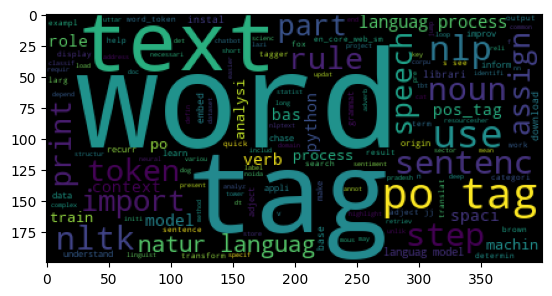

In [54]:
#!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = nlp_processing(text_content)
wc = WordCloud(max_words=300).generate(text)
plt.imshow(wc)
plt.show()

<h2>SENTIMENT ANALYSIS - NLP</h2>
Understand the sentiment of the given text. To check if its positive sentence. Or, classify the text as Positive, Negative or Neutral text.


In [55]:
import pandas as pd
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer



In [56]:
link="https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/amazon.csv"
df = pd.read_csv(link)
print(df)

                                              reviewText  Positive
0      This is a one of the best apps acording to a b...         1
1      This is a pretty good version of the game for ...         1
2      this is a really cool game. there are a bunch ...         1
3      This is a silly game and can be frustrating, b...         1
4      This is a terrific game on any pad. Hrs of fun...         1
...                                                  ...       ...
19995  this app is fricken stupid.it froze on the kin...         0
19996  Please add me!!!!! I need neighbors! Ginger101...         1
19997  love it!  this game. is awesome. wish it had m...         1
19998  I love love love this app on my side of fashio...         1
19999  This game is a rip off. Here is a list of thin...         0

[20000 rows x 2 columns]


In [57]:
df['FormatText'] = df['reviewText'].apply(nlp_processing)
print(df.head(2))

                                          reviewText  Positive  \
0  This is a one of the best apps acording to a b...         1   
1  This is a pretty good version of the game for ...         1   

                                          FormatText  
0  is one the best app acord bunch peopl i agre h...  
1  is pretti good version the game be free . are ...  


In [58]:
analyzer = SentimentIntensityAnalyzer()

#function to find if the given text is positive or not
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment


In [59]:
text1 = "This product is great"
print(get_sentiment(text1))

df['Sentiment'] = df['FormatText'].apply(get_sentiment)
print(df.head())

1
                                          reviewText  Positive  \
0  This is a one of the best apps acording to a b...         1   
1  This is a pretty good version of the game for ...         1   
2  this is a really cool game. there are a bunch ...         1   
3  This is a silly game and can be frustrating, b...         1   
4  This is a terrific game on any pad. Hrs of fun...         1   

                                          FormatText  Sentiment  
0  is one the best app acord bunch peopl i agre h...          1  
1  is pretti good version the game be free . are ...          1  
2  is realli cool game . are bunch level you find...          1  
3  is silli game can frustrat , lot fun definit r...          1  
4  is terrif game ani pad . hr fun . grandkid lov...          1  


In [61]:
#Evaluate our analysis
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy Score: ",accuracy_score(df['Sentiment'],df['Positive']))
print("Confusion Matrix: \n",confusion_matrix(df['Sentiment'],df['Positive']))

Accuracy Score:  0.77515
Confusion Matrix: 
 [[ 1403  1133]
 [ 3364 14100]]
